# **02 — ETA Prediction Model**
## **Ma3 | LSTM-based Matatu Arrival Time Estimator**

We train an LSTM (Long Short-Term Memory) neural network to predict
how many minutes until a matatu reaches the next stop.

**Why LSTM?**
ETA is a sequence problem — traffic at 7 AM affects 7:05 AM.
LSTM captures that temporal dependency better than a flat model.

**Input features:**
- `hour`, `day_of_week`, `stop_sequence`, `pax_count`, `speed_kmh`, `is_peak`

**Target:**
- `eta_minutes`

**Output:**
- Trained model saved to `ml/models/eta_model.joblib`
- Scaler saved to `ml/models/eta_scaler.joblib`

In [1]:
import numpy as np
import pandas as pd
import joblib
import os
import warnings
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

DATA_DIR  = "../data"
MODEL_DIR = "../models"
os.makedirs(MODEL_DIR, exist_ok=True)

print(f"TensorFlow: {tf.__version__} ✓")

I0000 00:00:1779558609.862997    3764 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779558616.834584    3764 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow: 2.21.0 ✓


## **Step 1 — Load & Explore Data**

In [2]:
df = pd.read_csv(f"{DATA_DIR}/eta_dataset.csv")
print(f"Shape: {df.shape}")
print(df.dtypes)
print("\nTarget distribution:")
print(df["eta_minutes"].describe().round(2))

Shape: (38880, 9)
route             object
stop_name         object
stop_sequence      int64
hour               int64
day_of_week        int64
pax_count          int64
speed_kmh        float64
is_peak            int64
eta_minutes      float64
dtype: object

Target distribution:
count    38880.00
mean        10.73
std          4.40
min          2.40
25%          7.40
50%          9.80
75%         13.40
max         25.30
Name: eta_minutes, dtype: float64


## **Step 2 — Feature Engineering**

We one-hot encode the route so the model distinguishes between
CBD-Westlands (shorter, more traffic) and CBD-Kikuyu (longer, highway).

In [3]:
# One-hot encode route
df = pd.get_dummies(df, columns=["route", "stop_name"], drop_first=True)

FEATURES = [
    "hour", "day_of_week", "stop_sequence",
    "pax_count", "speed_kmh", "is_peak"
] + [c for c in df.columns if c.startswith("route_") or c.startswith("stop_name_")]

TARGET = "eta_minutes"

X = df[FEATURES].values
y = df[TARGET].values

print(f"Features: {len(FEATURES)}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Sample features: {FEATURES[:6]}")

Features: 16
X shape: (38880, 16)
y shape: (38880,)
Sample features: ['hour', 'day_of_week', 'stop_sequence', 'pax_count', 'speed_kmh', 'is_peak']


## **Step 3 — Scale & Split**

- StandardScaler normalizes features to mean=0, std=1.
- We save the scaler — FastAPI uses it at inference time too.

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Save scaler immediately
joblib.dump(scaler, f"{MODEL_DIR}/eta_scaler.joblib")
print("Scaler saved ✓")

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Reshape for LSTM: (samples, timesteps, features)
# We treat each row as 1 timestep
X_train_lstm = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_lstm  = X_test.reshape((X_test.shape[0],  1, X_test.shape[1]))

print(f"Train: {X_train_lstm.shape}  Test: {X_test_lstm.shape}")

Scaler saved ✓
Train: (31104, 1, 16)  Test: (7776, 1, 16)


## **Step 4 — Build LSTM Model**

Architecture:
- LSTM(64) → captures temporal traffic patterns
- Dropout(0.2) → prevents overfitting
- LSTM(32) → refines sequence features
- Dense(16, relu) → non-linear combination
- Dense(1) → ETA in minutes (regression output)

In [5]:
n_features = X_train_lstm.shape[2]

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(1, n_features)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse", metrics=["mae"])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 64)          │        20,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,697 (131.63 KB)

 Trainable params: 33,697 (131.63 KB)

 Non-trainable params: 0 (0.00 B)

## **Step 5 — Train**

- EarlyStopping watches validation loss.
- If it stops improving for 5 epochs, training halts automatically.
- This prevents wasted time and overfitting.

In [6]:
early_stop = EarlyStopping(
    monitor="val_loss", patience=5,
    restore_best_weights=True, verbose=1
)

history = model.fit(
    X_train_lstm, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 31.9415 - mae: 3.7396 - val_loss: 1.0449 - val_mae: 0.8023
Epoch 2/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 2.4956 - mae: 1.2323 - val_loss: 0.7934 - val_mae: 0.7070
Epoch 3/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 2.1477 - mae: 1.1370 - val_loss: 0.7318 - val_mae: 0.6792
Epoch 4/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 1.9759 - mae: 1.0878 - val_loss: 0.6910 - val_mae: 0.6613
Epoch 5/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 1.7976 - mae: 1.0379 - val_loss: 0.6909 - val_mae: 0.6599
Epoch 6/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 1.7046 - mae: 1.0098 - val_loss: 0.6698 - val_mae: 0.6507
Epoch 7/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 1.6272 - mae: 0.9883 - val_loss: 0.7768 - val_mae: 0.7012
Epoch 8/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 1.5565 - mae: 0.9646 - val_loss: 0.6745 - val_mae: 0.6542
Epoch 9/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - l

## **Step 6 — Evaluate & Plot Loss Curves**

243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
MAE  (mean absolute error): 0.65 minutes
RMSE (root mean sq error):  0.82 minutes


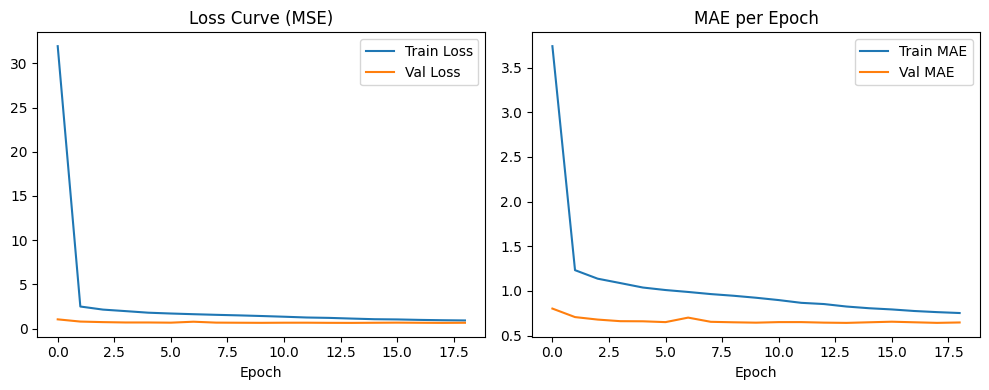

Loss curve saved ✓


In [7]:
y_pred = model.predict(X_test_lstm).flatten()

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE  (mean absolute error): {mae:.2f} minutes")
print(f"RMSE (root mean sq error):  {rmse:.2f} minutes")

# Loss curve
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"],     label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Loss Curve (MSE)")
plt.xlabel("Epoch"); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["mae"],     label="Train MAE")
plt.plot(history.history["val_mae"], label="Val MAE")
plt.title("MAE per Epoch")
plt.xlabel("Epoch"); plt.legend()

plt.tight_layout()
plt.savefig(f"{MODEL_DIR}/eta_loss_curve.png", dpi=100)
plt.show()
print("Loss curve saved ✓")

## **Step 7 — Prediction Sanity Check**

Test the model on realistic Nairobi scenarios before saving.

In [8]:
def predict_eta(hour, day_of_week, stop_sequence, pax_count, speed_kmh, is_peak):
    sample = np.zeros(len(FEATURES))
    sample[FEATURES.index("hour")]           = hour
    sample[FEATURES.index("day_of_week")]    = day_of_week
    sample[FEATURES.index("stop_sequence")]  = stop_sequence
    sample[FEATURES.index("pax_count")]      = pax_count
    sample[FEATURES.index("speed_kmh")]      = speed_kmh
    sample[FEATURES.index("is_peak")]        = is_peak
    scaled = scaler.transform(sample.reshape(1, -1))
    lstm_in = scaled.reshape(1, 1, len(FEATURES))
    return round(float(model.predict(lstm_in, verbose=0)[0][0]), 1)

scenarios = [
    {"label": "Mon 8AM peak, CBD stop, full matatu, slow", 
     "args": (8, 0, 1, 14, 12, 1)},
    {"label": "Sat 2PM offpeak, mid-route, half full, fast",
     "args": (14, 5, 3, 7, 45, 0)},
    {"label": "Fri 6PM peak, last stop, empty, crawling",
     "args": (18, 4, 4, 2, 8, 1)},
]

print(f"{'Scenario':<50} {'ETA':>8}")
print("-" * 60)
for s in scenarios:
    eta = predict_eta(*s["args"])
    print(f"{s['label']:<50} {eta:>6.1f} min")

Scenario                                                ETA
------------------------------------------------------------
Mon 8AM peak, CBD stop, full matatu, slow            10.7 min
Sat 2PM offpeak, mid-route, half full, fast           6.6 min
Fri 6PM peak, last stop, empty, crawling             15.2 min


In [9]:
# Save Keras model as joblib-wrapped for FastAPI compatibility
# We wrap it so loader.py handles it uniformly with sklearn models

class KerasETAWrapper:
    def __init__(self, keras_model, scaler, features):
        self.model    = keras_model
        self.scaler   = scaler
        self.features = features

    def predict(self, X):
        scaled = self.scaler.transform(X)
        lstm_in = scaled.reshape(scaled.shape[0], 1, scaled.shape[1])
        return self.model.predict(lstm_in, verbose=0).flatten()

wrapper = KerasETAWrapper(model, scaler, FEATURES)
joblib.dump(wrapper, f"{MODEL_DIR}/eta_model.joblib")

print("=" * 40)
print(f"Model saved → models/eta_model.joblib")
print(f"MAE:  {mae:.2f} min  |  RMSE: {rmse:.2f} min")
print(f"Epochs run: {len(history.history['loss'])}")
print("Ready for 03_demand_forecast.ipynb ✓")
print("=" * 40)

Model saved → models/eta_model.joblib
MAE:  0.65 min  |  RMSE: 0.82 min
Epochs run: 19
Ready for 03_demand_forecast.ipynb ✓
